<a href="https://colab.research.google.com/github/trevorlillywhite/HW7-NCSU-ST-554-Trevor-Lillywhite/blob/main/HW7_ST554_Lillywhite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Homework 7 - NCSU ST 554
### Author: Trevor Lillywhite
### Due Date: March 31, 2026

**Purpose:** Practice fitting multiple linear regression (MLR) and logistic regression models, including penalization/regulatrization.


**Data:**
+ This assignment will use the wine quality dataset from the UCI Machine Learning Repository. We will combine the `winequality-red.csv` and `winequality-white.csv` files and indicate which color each row corresponds to.
+ Although the typical response variable is `quality`, we will predict `alcohol` content for the multiple linear regression models and the type of wine for logistic regression models.
+ There are nearly a dozen input variables based on physiochemical tests (e.g., `fixed acidity`, `chlorides`, `pH`, etc.).

#### Read in and Combine Data

We will read in the two csv files separately, add a new feature (`type` as `white` or `red`), and then merge the two datasets.

In [57]:
# Import relevant modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import mean_squared_error, mean_absolute_error, \
        log_loss, accuracy_score
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, \
        LogisticRegression, LogisticRegressionCV, ElasticNet, ElasticNetCV
from sklearn.preprocessing import PolynomialFeatures

In [30]:
# Import red dataset
df_red = pd.read_csv('winequality-red.csv', sep=';')

# Make new feature
df_red['type'] = 1          # We will encode our colors as red = 1, white = 0

# Check first few rows
df_red.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,1
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,1
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,1


It looks like the data was properly read in, and the color column was successfully added.

In [31]:
# Check data types
df_red.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
 12  type                  1599 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 162.5 KB


There are no missing values (as expected), but we should encode the `color` feature using dummy variables. We will do this after reading in the white wine dataset and combining the datasets.

In [32]:
# Import white dataset
df_white = pd.read_csv('winequality-white.csv', sep=';')

# Make new feature
df_white['type'] = 0

# Check first few rows
df_white.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6,0
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6,0
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6,0
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,0
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6,0


It looks like the data was properly read in, and the color was successfully added.

In [33]:
# Check data types
df_white.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
 12  type                  4898 non-null   int64  
dtypes: float64(11), int64(2)
memory usage: 497.6 KB


The columns and data types match, which is good. However, there are many more red wine observations, so we will need to account for this imbalanced dataset later.

In [34]:
# Combine dataframes
df = pd.concat([df_red, df_white], axis=0)

# Check around the expected transition point
df.iloc[1597:1602, :]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6,1
0,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6,0
1,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6,0
2,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6,0


We need to reset the index!

In [35]:
# Reset index
df.reset_index(drop = True, inplace = True)

# Check again
df.iloc[1597:1602, :]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,1
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6,1
1599,7.0,0.270,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6,0
1600,6.3,0.300,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6,0
1601,8.1,0.280,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6,0


The index was successfully reset! The two datasets are now in one unified dataframe.

#### Split the Data

We will use stratified sampling to ensure the colors are proportionally represented in the training and test sets. We will also shuffle to remove any dataset ordinality.

At first, we will only split our dataset for regression. Classification will be split later

In [45]:
# Split training and test set
X_train, X_test, y_train, y_test = train_test_split(
    df.drop('alcohol', axis=1),
    df['alcohol'],
    test_size = 0.20,
    shuffle = True,
    random_state = 42,
    stratify = df['type']
)

# Print observation counts and type proportions to check the split
print(len(X_train))
print(len(X_test))
print(X_train.type.value_counts())

5197
1300
type
0    3918
1    1279
Name: count, dtype: int64


The split occurred successfully. The training set has four times the number of observations as the test set (80/20 split).

The stratification also looks like it worked. The `type` proportions look correct.

## Regression Task

### Train Models

#### Multiple Linear Regression Models

Below, we will fit four different MLR models meeting the following requirements.
+ At least one will include interaction terms.
+ At least one will include some polynomial terms.
+ Cross Validation (CV) will be used to select the best MLR model.

Before deciding which models to create, let's do some quick EDA! The `seaborn pairplot()` function is a powerful tool to quickly visualize univariate and bivariate feature distributions.  


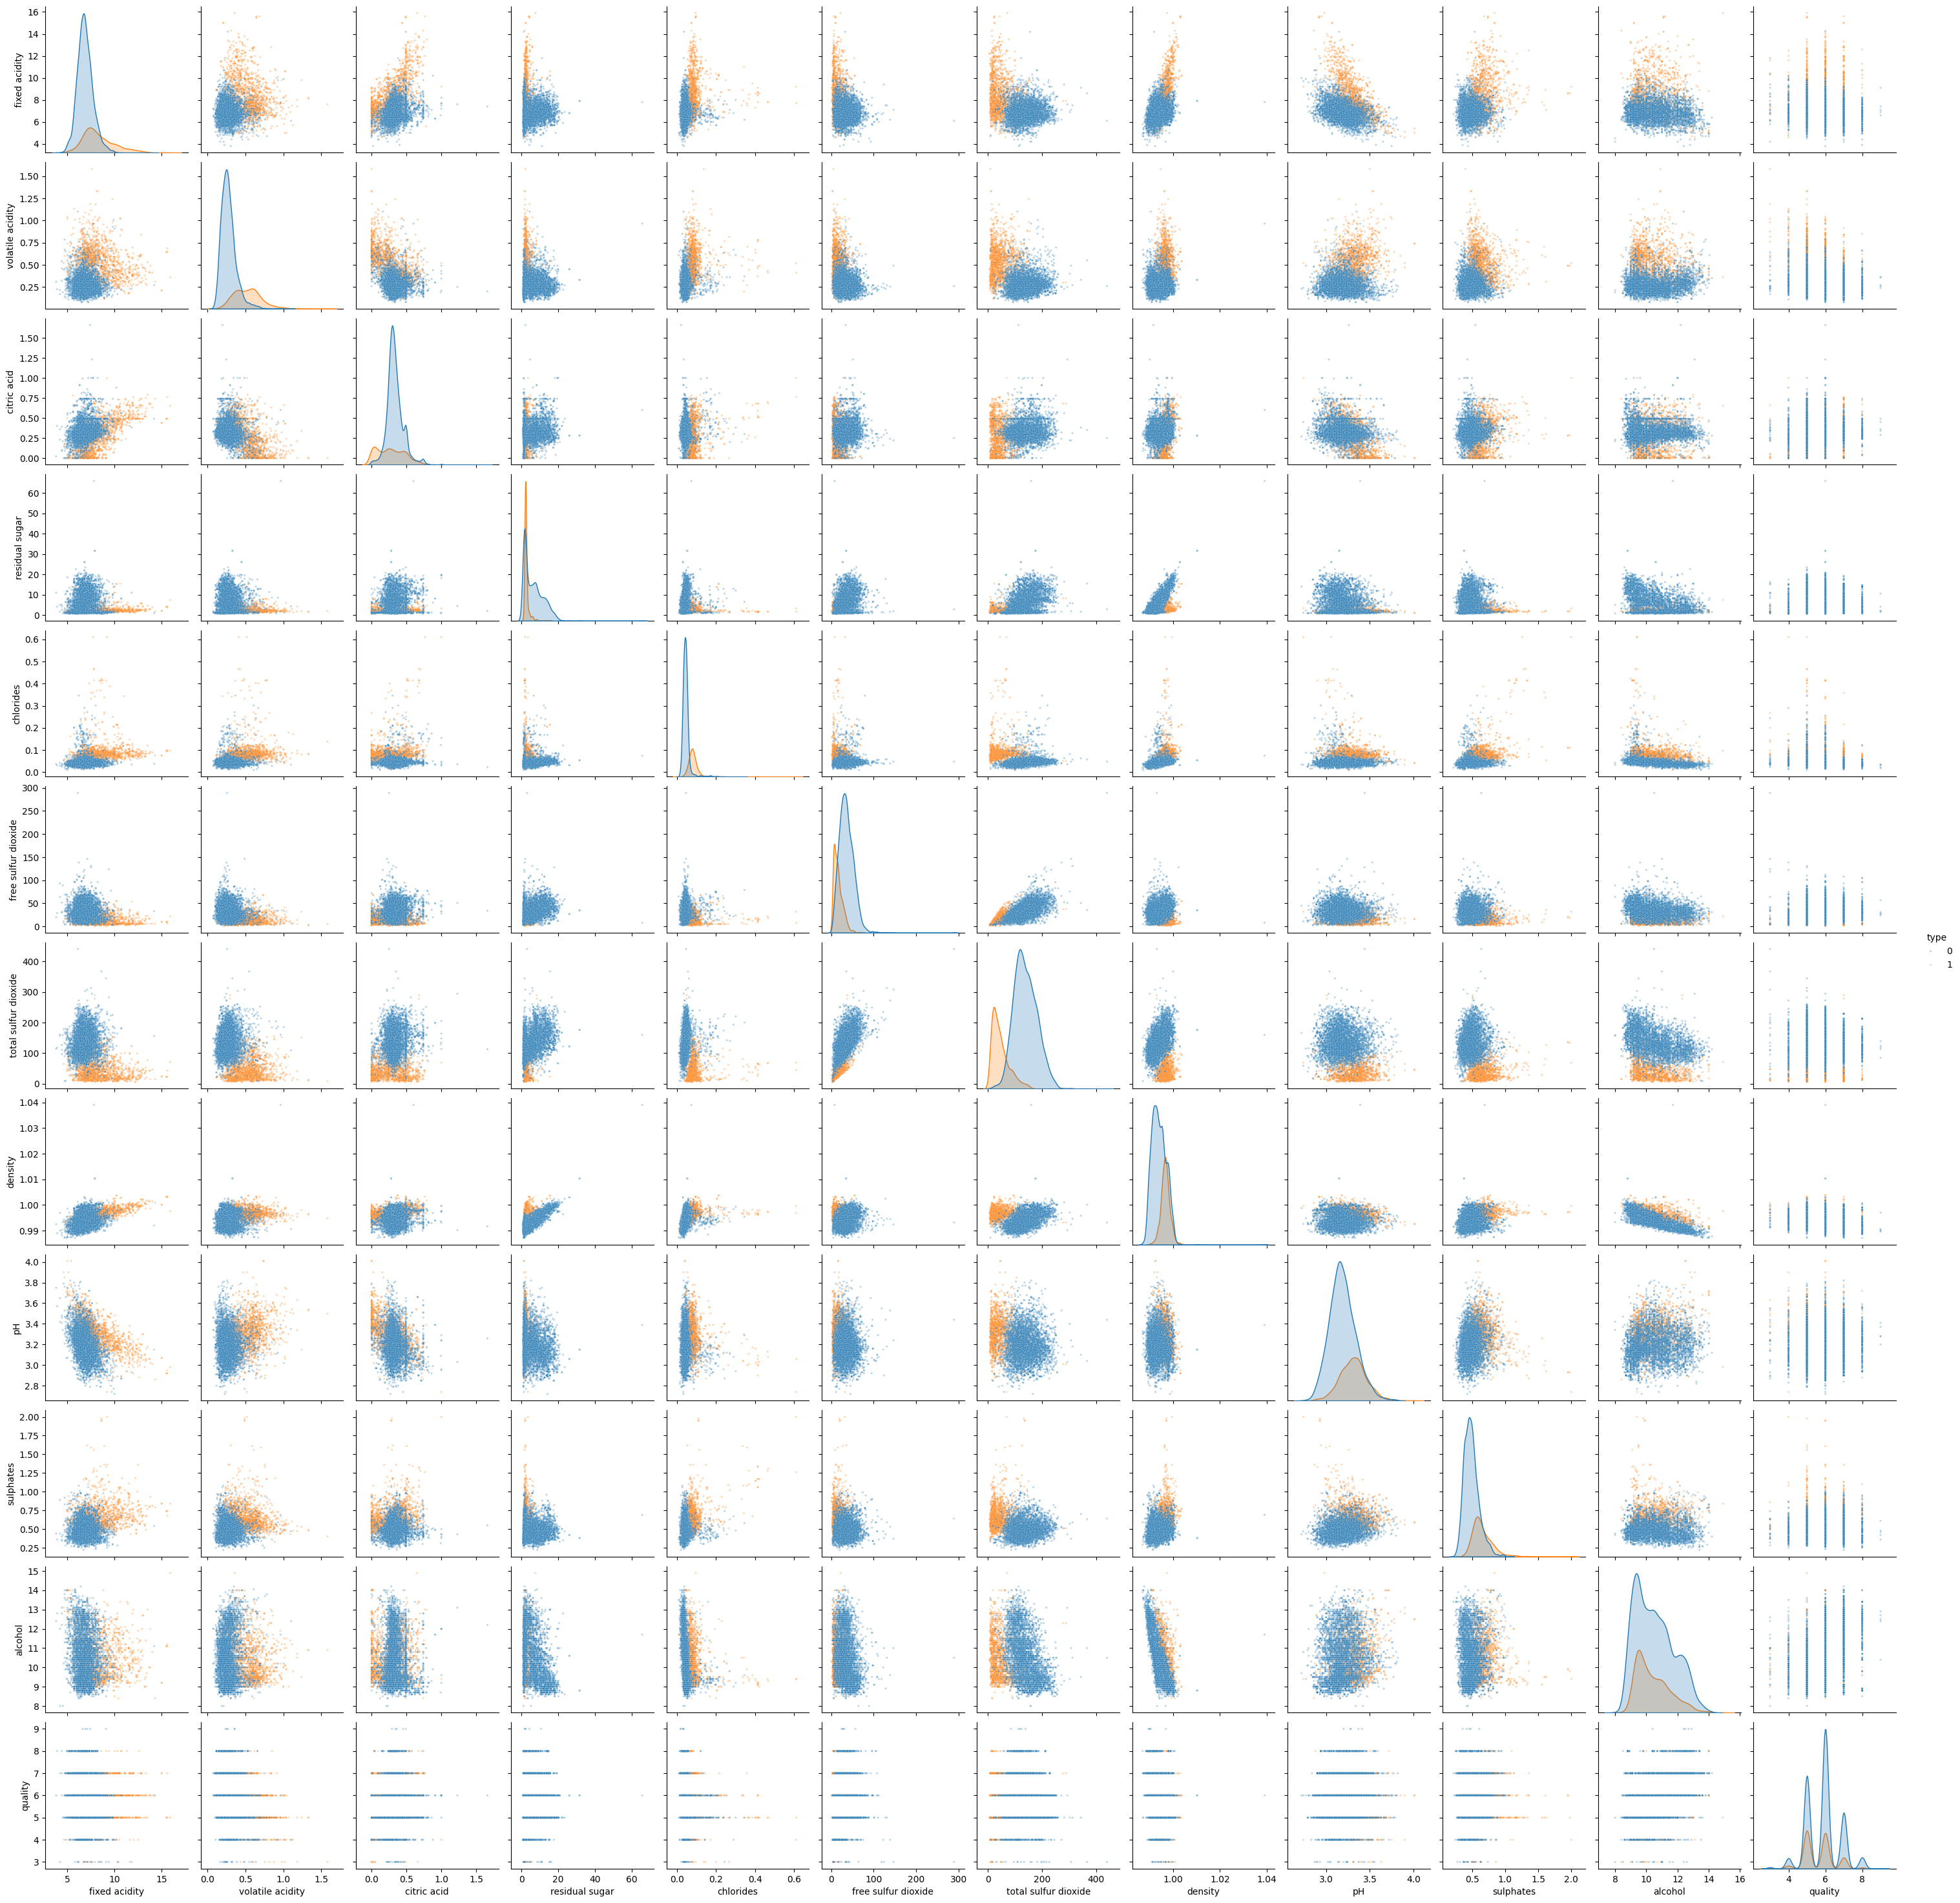

In [51]:
# Create pairplot
sns.pairplot(df,
             hue='type',                # color points by type (white or red)
             plot_kws={'alpha': 0.3,    # increase transparency to see points stacking up
                       's': 5}          # decrease point size
             )

_Tip: Because there are so many plots packed in, it is highly recommended that you zoom in to see the axes and data. The legend at the far right-hand side shows that the blue dots correspond to white wine and the orange dots correspond to red wine._


What do we see in this wealth of data?


+ Univariate distributions (histograms along the diagonal)
    - Red wines tend to have a different unvariate distribution than white wines for most features. The features that are the least dependent on `type` include `alcohol` and `quality`.
    - This indicates that 'type' is likely an important fact to consider, though it cannot be used alone to predict `alcohol`.
+ Positive bivariate correlations
    - `density` vs. `fixed acidity` has a moderate positive correlation
    - For white wines, `density` and `residual sugar` also have a moderate positive correlation
    - Unfortunately, due to the lack of very strong bivariate correlations, we are unable to discount any features out-right for providing redundant value in relation to another feature.
+ Bivariate correlations with the target variable (`alcohol`)
    - There are no great correlations to take advantage of. The closest might be `alcohol` vs. `density`, particularly for the white wines.

Now, we will explore the correlation matrix shown as a heatmap. Highly correlated variables don't necessarily need to be used simultaneously as inputs because they communicate much of the same information.

On the other hand, any variable highly correlated with the target variable will be of great interest.

Text(0.5, 1.0, 'All Wines - Correlation Matrix Heatmap')

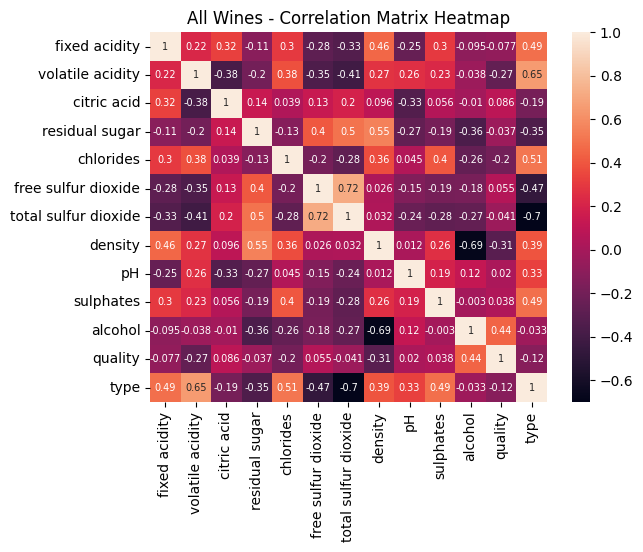

In [59]:
# Produce correlation heatmap
sns.heatmap(df.corr(), annot=True, annot_kws={"size": 7})
plt.title('All Wines - Correlation Matrix Heatmap')

What do we see here?

+ To confirm our pairplot() findings, we see that no two separate variables are highly correlated with each other. The most extreme values are:
    - -0.7 for `total sulfur dioxide` vs. `type`
    - -0.69 for `alcohol` vs. `density`
    - 0.65 for `volatile acidity` vs. `type`

+ The features most correlated with `alcohol` are:
    - density (-0.69)
    - quality (0.44)
    - residual sugar (-0.36)

These don't seem great for predictive power, so we will likely need to rely on interactions or polynomials, if chosen smartly.

To see how a third variable of `type` affects things, let's repeat this correlation matrix heatmap while splitting the data by type.

Text(0.5, 1.0, 'Red Wines - Correlation Matrix Heatmap')

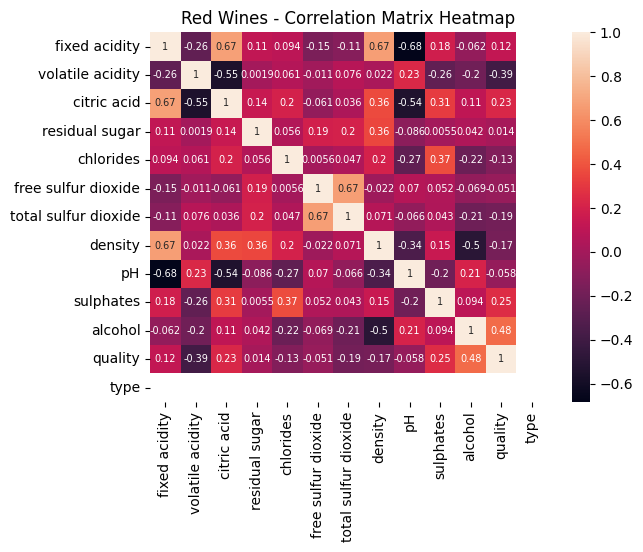

In [58]:
# Create correlation matrix heatmap split by wine type
#   First: red wine

sns.heatmap(df.loc[df['type'] == 1].corr(), annot=True, annot_kws={"size": 7})
plt.title('Red Wines - Correlation Matrix Heatmap')

This was useful. We see some new correlation trends sticking out.
+ Because we won't filter out features that are redundant for only some of the wine types, we won't further analyze the most extreme correlation values that are generally present in the matrix. We will focus on correlations with `alcohol` content.
+ `Alcohol` now has less extreme correlations. The strongest are with:
    - `density` (-0.5) (less significant correlation than with the full dataset)
    - `quality` (0.48) (slightly higher correlation than with the full dataset)

Now we will repeat for white wine.

Text(0.5, 1.0, 'White Wines - Correlation Matrix Heatmap')

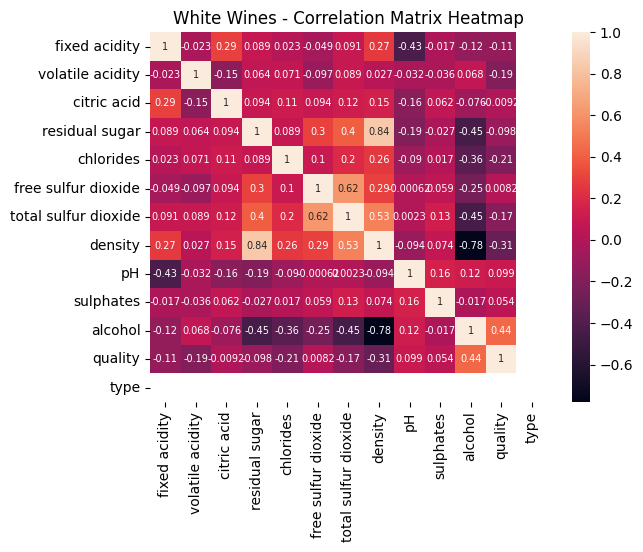

In [60]:
# Create correlation matrix heatmap split by wine type
#   Second: white wine

sns.heatmap(df.loc[df['type'] == 0].corr(), annot=True, annot_kws={"size": 7})
plt.title('White Wines - Correlation Matrix Heatmap')

As expected, the correlation between `alcohol` and `density` had to become more significant here since it became less significant with red wines (vs. the whole dataset). Correlations with `alcohol` vs. `total sulfur dioxide` and `residual sugar` are both more pronounced now, each at -0.45.

Overall, we need to account for wine type and density, at a very minimum.

Now we have enough data to make semi-informed decisions about how to craft our models. Because these will not be regularized, we will be judicious about the number of features selected.

+ MLR Model 1 (most simple)
    - Features: `type`, `density`, `quality`
    - Interactions: None
    - Polynomials: None

+ MLR Model 2 (still simple but more features)
    - Features: `type`, `density`, `quality`, `residual sugar`, `total sulfur dioxide`
    - Interactions: None
    - Polynomials: None

+ MLR Model 3 (adding complexity with interaction terms)
    - Features: `type`, `density`, `quality`, `residual sugar`, `total sulfur dioxide`
    - Interactions:
        - `type` * `density`
        - `type` * `residual sugar`
        - `type` * `total sulfur dioxide`
    - Polynomials: None

+ MLR Model 4 (most complex - includes interactions and polynomials)
    - Features: `type`, `density`, `quality`, `residual sugar`, `total sulfur dioxide`
    - Interactions:
        - `type` * `density`
        - `type` * `residual sugar`
        - `type` * `total sulfur dioxide`
    - Polynomials:
        - `residual sugar`^2
        - `total sulfur dioxide`^2
        - `density`^2

The interaction terms were chosen based on the features whose correlation with `alcohol` was most affected by `type`.

The polynomial terms were chosen based on the visible data curvature in the `pairplot()` bivariate distributions with `alcohol`. The exponent should make the correlation more pronounced for at least one of the wine types.